While the PRISM-G components provide a quantitative assessment of privacy risk, it is often useful to check which samples are prone to an attack. This module provides tools for identifying vulnerable samples using the PLI submetrics by identifying holdout individuals that are unusually close to synthetic samples, and visualizing the distance relationships between real and synthetic samples.

The easiest way to perform a complete PLI diagnostic analysis is with the `pli_diagnostics()` function. This function computes the PLI component together with several diagnostic outputs in a single call. Us

Using the training and holdout sets of the real genotype and the synthetic one, the object returns:

- `pli`: complete output of `compute_pli()`.
- `driver`: indicates which PLI sub-metric dominates the final score (`ratio_tail` or `adv_proximity`).
- `per_sample`: per-sample proximity diagnostics.
- `boot`: bootstrap estimates for assessing score stability.

In [1]:
import numpy as np
from prismg.io import vcf_reader as vcfio

# Real dataset
REAL_VCF = "../example_data/1000G_10K_SNP_chr15.vcf.gz"
# SNP Positions
LEGEND   = "../example_data/10K_SNP.legend"
legend_keys = vcfio.load_snp_legend_pos_keys(LEGEND)
real_samples, _, real_G = vcfio.load_vcf(REAL_VCF, keep_pos=legend_keys)

# Synthetic datasets
GAN_VCF  = "../example_data/GAN_10K_SNP_chr15.vcf.gz"
_,  _,  gan_G  = vcfio.load_vcf(GAN_VCF,  keep_pos=legend_keys)

RANDOM_SEED   = 123
TRAIN_FRAC    = 0.8

rng = np.random.RandomState(RANDOM_SEED)
idx = np.arange(len(real_samples))
rng.shuffle(idx)
cut = int(len(idx) * TRAIN_FRAC)
tr_idx, ho_idx = idx[:cut], idx[cut:]

R_tr_samples = [real_samples[i] for i in tr_idx]
R_ho_samples = [real_samples[i] for i in ho_idx]
G_tr, G_ho   = real_G[tr_idx, :], real_G[ho_idx, :]

In [2]:
from prismg.utils.diag import pli_diagnostics, plot_dsyn_dreal_per_sample, plot_identifiability_scatter

N_COMPONENTS = 10
Q_LOWER = 0.01
N_BOOT = 10

diag = pli_diagnostics(G_tr, G_ho, gan_G, ho_names=R_ho_samples, n_components=N_COMPONENTS, q=Q_LOWER, random_seed=RANDOM_SEED, boot=N_BOOT)

The `per_sample` table summarizes the contribution of each holdout individual to the PLI score.

In [3]:
print(diag["per_sample"].head(10).to_string(index=False))

 sample     d_syn    d_real  ratio_dsyn_dreal  margin_dreal_minus_dsyn  s_ratio  ap_flag  rank_s_ratio  rank_margin
HG01176 11.136981 32.851195          0.339013                21.714215 0.660987        1             1            1
NA20355 10.496459 28.470679          0.368676                17.974219 0.631324        1             2            2
HG02230  7.258502 19.193174          0.378181                11.934672 0.621819        1             3            9
HG01356  7.686624 18.827495          0.408266                11.140871 0.591734        1             4           12
NA12249 10.410753 24.981286          0.416742                14.570533 0.583258        1             5            4
HG03762 11.772275 28.076922          0.419287                16.304646 0.580713        1             6            3
HG02367  8.535519 19.469749          0.438399                10.934230 0.561601        1             7           14
HG01177 11.912036 26.005091          0.458066                14.093056 0

Each row corresponds to one holdout sample and includes:

| Column | Description |
|---------|-------------|
| `d_syn` | Distance to the nearest synthetic sample. |
| `d_real` | Distance to the nearest holdout neighbour. |
| `ratio_dsyn_dreal` | Ratio between synthetic and real neighbour distances. |
| `margin_dreal_minus_dsyn` | Difference between baseline and synthetic distances. |
| `s_ratio` | Per-sample proximity score. |
| `ap_flag` | Indicates whether the synthetic neighbour is closer than the real neighbour. |
| `rank_s_ratio` | Ranking according to proximity risk. |

Samples with large margins, small distance ratios, and high `s_ratio` values contribute most strongly to the final PLI score.

The bootstrap summary provides empirical confidence intervals for:

- Quantile tails ($\rho_q$) 
- Quantile proximity ratio ($r_P$)
- Adversarial accuracy measurement ($A$)
- Adversarial proximity ($r_A$)
- PLI component

Stable datasets generally exhibit small bootstrap variability, whereas large confidence intervals indicate that the estimated PLI score is sensitive to the sampled holdout individuals.

In [4]:
print("\nBootstrap stability summary:")
print(diag["boot"].describe(percentiles=[0.025, 0.5, 0.975]).round(4).to_string())


Bootstrap stability summary:
         rho_q      r_p        A      r_A      PLI
count  10.0000  10.0000  10.0000  10.0000  10.0000
mean    1.0727   0.0051   0.3561   0.2878   0.2878
std     0.0598   0.0163   0.0287   0.0573   0.0573
min     0.9485   0.0000   0.3174   0.2016   0.2016
2.5%    0.9681   0.0000   0.3178   0.2061   0.2061
50%     1.0693   0.0000   0.3583   0.2834   0.2834
97.5%   1.1620   0.0399   0.3970   0.3644   0.3644
max     1.1656   0.0515   0.3992   0.3653   0.3653


### Visualizing per-sample distances

The function `plot_dsyn_dreal_per_sample()` compares, for each holdout sample, the distance to its nearest synthetic neighbour with the distance to its nearest real neighbour. The `sort_by` argument controls how the samples are ordered in the plot:

- `"margin"` (default): sorts samples by the difference $d_{\mathrm{real}} - d_{\mathrm{syn}}$. Samples with the largest positive margin, corresponding to the strongest proximity leakage, appear first.
- `"ratio"`: sorts samples by the distance ratio $d_{\mathrm{syn}} / d_{\mathrm{real}}$. Lower ratios indicate that synthetic neighbours are substantially closer than real neighbours.

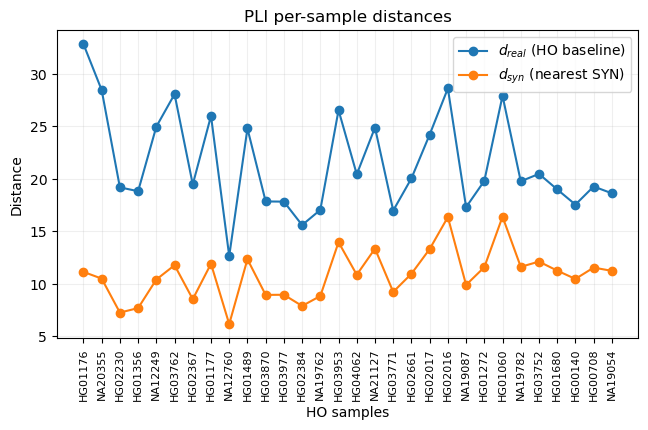

In [5]:
_, _, plot = plot_dsyn_dreal_per_sample(df=diag["per_sample"], sort_by="ratio", title="PLI per-sample distances", top_k = 30)

A complementary visualization is provided by `plot_identifiability_scatter()`. 

c:\Users\acorrear\AppData\Local\anaconda3\envs\prismg\Lib\site-packages\prismg\utils\diag.py:352: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


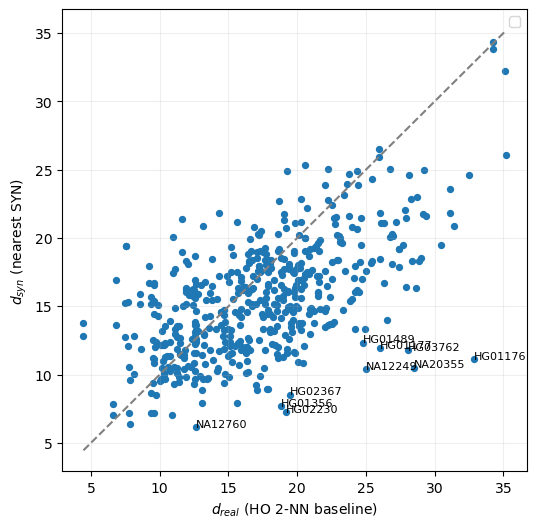

In [6]:
_, _, plot = plot_identifiability_scatter(df=diag["per_sample"], annotate_top_k=10, title="PLI identifiability scatter")

Each point represents one holdout individual.

- Points below the diagonal correspond to individuals whose nearest synthetic neighbour is closer than their nearest real neighbour.
- Points farther below the diagonal indicate stronger evidence of proximity leakage.
- The highest-risk individuals can optionally be annotated.